# P.6. Callable Agency Bond OAS Strategy


## Project Statement

Analyze a panel of callable agency bonds (Freddie Mac, Fannie Mae, FHLB), construct a mean-reversion trading strategy based on OAS z-scores, and decompose the strategy’s P&L into spread compression, option repricing, and carry components across the 2022–2025 rate cycle.


## Context

### Agency Callable Bonds and the Ch 6 Framework

Agency callable bonds are the canonical application of the OAS framework from Ch 6. The bondholder is short an embedded call option: the issuer (Freddie Mac, Fannie Mae, or FHLB) can redeem the bond at par after the first call date. This creates the decomposition:

$$\text{Z-spread} = \text{OAS} + \text{Option Cost}$$

The **Z-spread** is the flat spread over the swap curve needed to match the bond's market price, ignoring the call option. The **OAS** (option-adjusted spread) accounts for the issuer's call right using a rate model. The difference is the **option cost**—the compensation the bondholder demands for being short the call.

### Why OAS for Trading Signals

Raw spread measures (Z-spread, yield spread) conflate two effects: (1) whether the bond is cheap or expensive relative to its credit, and (2) whether the embedded option is expensive or cheap. When implied volatility rises, the option cost increases, widening the Z-spread even if the bond's credit hasn't changed. A naive Z-spread signal would misidentify this as a buying opportunity.

OAS strips out the option effect. If OAS is wide relative to recent history (after accounting for the call), the bond is genuinely cheap. A mean-reversion strategy buys wide-OAS bonds and sells tight-OAS bonds, betting on spread normalization.

### The 2022–2025 Rate Cycle

The sample period spans a dramatic rate environment:

| Period              | Regime            | Fed Funds      | Effect on Callables                              |
|---------------------|-------------------|----------------|--------------------------------------------------|
| Jan 2022 – Sep 2022 | Hiking starts     | 0.25% → ~3.25% | High-coupon calls go from ITM to ATM             |
| Oct 2022 – Jun 2023 | Aggressive hiking | ~3.25% → 5.25% | Calls move OTM, option cost changes dramatically |
| Jul 2023 – Aug 2024 | Pause at peak     | 5.25–5.50%     | Stable option cost, carry matters                |
| Sep 2024 – Dec 2025 | Easing begins     | 5.50% → 4.50%+ | Calls drift back toward ATM                      |

This creates rich variation in call moneyness, option cost, and OAS behavior—exactly the variation needed to study when and why an OAS-based strategy works.

## Resources

### Course Materials

| Material | Relevance |
|----------|-----------|
| **D.5.1 Swap Rates and Spreads** | Swap curve as benchmark for agency spreads, swap spread dynamics |
| **D.6.1 Callable Bonds** | OAS, option cost, negative convexity, Black's formula for the call |
| **E.6.2 Pricing a Callable Bond** | Single-bond OAS calculation (this project scales to a panel) |
| **C.6.1 Callable Bond Analysis** | Freddie Mac callable bond case study |

### External Reading

- [FHLB Office of Finance — Debt Securities](https://www.fhlb-of.com/ofweb_userWeb/pageBuilder/debt-securities-702) — Overview of FHLB callable bond issuance
- [Fannie Mae — Debt Securities](https://capitalmarkets.fanniemae.com/debt-securities) — Fannie Mae callable debt programs
- [NY Fed — Agency Debt and MBS Purchase Program](https://www.newyorkfed.org/markets/agency-debt-and-agency-mbs) — Fed purchases, agency market structure and supply dynamics

### Data Files

| File | Description | Frequency | Date Range |
|------|-------------|-----------|------------|
| `callable_agency_panel_2026-03-03.xlsx` | Panel of agency callable bonds (OAS, prices, analytics) | Daily | 2022–2025 |
| `sofr_swaps.xlsx` | SOFR swap curve (41 maturities) | Daily | 2018–2025 |
| `gsw_yields.xlsx` | GSW zero-coupon Treasury yields (1–30Y) | Daily | 1961–2025 |
| `ref_rates.xlsx` | SOFR, Fed Funds, 3M T-bill | Daily | 2018–2025 |

**Panel structure**: The callable agency panel contains 26 bonds from Freddie Mac, Fannie Mae, and FHLB, spanning coupons from ~1% to ~5.5% and maturities from 2027 to 2036. The Excel file contains:

| Sheet | Description | Coverage |
|-------|-------------|----------|
| `info` | Static properties (coupon, maturity, call dates, issuer) | All 26 bonds |
| `quotes` | Snapshot analytics (OAS, Z-spread, eff. duration, eff. convexity, implied vol) | 16 bonds with live analytics |
| `oas` | Daily OAS time series | 25 bonds, 2022–2025 |
| `z_spread` | Daily Z-spread time series | 15 bonds |
| `option_cost` | Daily option cost = Z-spread − OAS | 15 bonds |
| `clean_prices` / `dirty_prices` | Daily prices | 15 bonds |
| `ytm` | Daily yield to maturity | 15 bonds |

**Note:** 25 bonds have OAS time series; 15 bonds also have Z-spread, prices, and option cost. The OAS-based strategy in Q2 can use all 25 bonds; the return decomposition in Q3 uses the 15 bonds with price data. Effective duration and convexity are available as snapshots only (in `quotes`), not as time series — use the snapshot values as constant approximations, or compute numerical duration from prices if you wish. Some high-coupon bonds in the panel were previously called by issuers; these retain historical OAS time series but lack current snapshot analytics (NaN in the `quotes` sheet). Be aware that bonds called by issuers during the sample period drop out of the panel — this survivorship effect may bias backtested returns, particularly for high-coupon bonds.

## Data Preview


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

DATA_PATH = Path('./data')

In [2]:
# Load callable agency panel (use most recent file)
panel_file = sorted(DATA_PATH.glob('callable_agency_panel_*.xlsx'))[-1]
print(f'Panel file: {panel_file.name}')

info = pd.read_excel(panel_file, sheet_name='info', index_col=0)
quotes = pd.read_excel(panel_file, sheet_name='quotes', index_col=0)
oas = pd.read_excel(panel_file, sheet_name='oas', index_col=0, parse_dates=True)
zsprd = pd.read_excel(panel_file, sheet_name='z_spread', index_col=0, parse_dates=True)
opt_cost = pd.read_excel(panel_file, sheet_name='option_cost', index_col=0, parse_dates=True)
clean = pd.read_excel(panel_file, sheet_name='clean_prices', index_col=0, parse_dates=True)
dirty = pd.read_excel(panel_file, sheet_name='dirty_prices', index_col=0, parse_dates=True)

oas.index = pd.to_datetime(oas.index)
zsprd.index = pd.to_datetime(zsprd.index)
opt_cost.index = pd.to_datetime(opt_cost.index)
clean.index = pd.to_datetime(clean.index)
dirty.index = pd.to_datetime(dirty.index)

print(f'Static bonds: {len(info.columns)}')
print(f'OAS time series: {oas.shape[1]} bonds, {oas.shape[0]} dates')
print(f'Prices/Z-spread: {clean.shape[1]} bonds')
print(f'Date range: {oas.index[0].date()} to {oas.index[-1].date()}')

Panel file: callable_agency_panel_2026-03-03.xlsx
Static bonds: 26
OAS time series: 25 bonds, 1043 dates
Prices/Z-spread: 15 bonds
Date range: 2022-01-03 to 2025-12-31


In [3]:
# Load supporting data
swaps = pd.read_excel(DATA_PATH / 'sofr_swaps.xlsx', sheet_name='data',
                       index_col=0, parse_dates=True)
swaps.index = pd.to_datetime(swaps.index)

gsw = pd.read_excel(DATA_PATH / 'gsw_yields.xlsx', index_col=0, parse_dates=True)
gsw.index = pd.to_datetime(gsw.index)

rates = pd.read_excel(DATA_PATH / 'ref_rates.xlsx', sheet_name='data',
                       index_col=0, parse_dates=True)
rates.index = pd.to_datetime(rates.index)

In [4]:
# Snapshot: bond properties and analytics
print('Bond Properties:')
display(info)

print('\nSnapshot Analytics:')
display(quotes)

Bond Properties:


,FHLB 2 01/28/31,FHLB 2 09/15/31,FHLB 4.25 03/28/30,FHLB 4.25 12/28/28,FHLB 4.75 06/15/28,FHLB 5 01/15/30,FHLB 5 09/28/32,FHLB 5 12/15/27,FHLB 5.25 03/28/29,FHLB 5.5 12/28/28,...,FHLMC 5.5 09/28/28,FNMA 1 09/28/29,FNMA 1.5 09/28/35,FNMA 5 03/15/30,FHLB 4.875 01/28/36,FHLB 4.875 09/28/28,FHLB 5.125 05/15/29,FHLB 5.25 05/15/35,FHLB 5.375 12/15/34,FHLB 5.5 05/15/34
info,,,,,,,,,,,,,,,,,,,,,
CUSIP,3130AKTB2,3130ANWL0,3130B5Q50,3130AYLD6,3130B6TU0,3130B4KU4,3130ATBY2,3130B43K5,3130B0M55,NaN,...,NaN,3136G44J9,3136G44Q3,3136GADR7,3130B96U9,3130B1GC5,3130B1HQ3,3130B65Z5,3130B4B59,3130B1EY9
Issuer,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,...,FREDDIE MAC,FANNIE MAE,FANNIE MAE,FANNIE MAE,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK,FEDERAL HOME LOAN BANK
Maturity Type,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,NaN,...,NaN,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE,CALLABLE
Amount Issued,30000000,50000000,30000000,60000000,50000000,100000000,50000000,230000000,40000000,NaN,...,NaN,50000000,25000000,15000000,55000000,25000000,30000000,105000000,20000000,15000000
Cpn Rate,0.02,0.02,0.0425,0.0425,0.0475,0.05,0.05,0.05,0.0525,0.055,...,0.055,0.01,0.015,0.05,0.04875,0.04875,0.05125,0.0525,0.05375,0.055
Cpn Freq,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
Date Issued,2021-01-28 00:00:00,2021-09-15 00:00:00,2025-03-28 00:00:00,2024-01-19 00:00:00,2025-06-30 00:00:00,2025-01-15 00:00:00,2022-09-28 00:00:00,2024-12-27 00:00:00,2024-03-28 00:00:00,NaN,...,NaN,2020-09-28 00:00:00,2020-09-28 00:00:00,2025-03-28 00:00:00,2026-01-28 00:00:00,2024-05-20 00:00:00,2024-05-29 00:00:00,2025-05-15 00:00:00,2024-12-18 00:00:00,2024-05-15 00:00:00
Date Matures,2031-01-28 00:00:00,2031-09-15 00:00:00,2030-03-28 00:00:00,2028-12-28 00:00:00,2028-06-15 00:00:00,2030-01-15 00:00:00,2032-09-28 00:00:00,2027-12-15 00:00:00,2029-03-28 00:00:00,2028-12-28 00:00:00,...,2028-09-28 00:00:00,2029-09-28 00:00:00,2035-09-28 00:00:00,2030-03-15 00:00:00,2036-01-28 00:00:00,2028-09-28 00:00:00,2029-05-15 00:00:00,2035-05-15 00:00:00,2034-12-15 00:00:00,2034-05-15 00:00:00
Date First Call,2021-04-28 00:00:00,2021-12-15 00:00:00,2028-03-28 00:00:00,2027-06-28 00:00:00,2025-09-15 00:00:00,2026-01-15 00:00:00,2023-09-28 00:00:00,2025-01-15 00:00:00,2025-03-28 00:00:00,NaN,...,NaN,2022-09-28 00:00:00,2022-09-28 00:00:00,2025-09-15 00:00:00,2026-07-28 00:00:00,2026-09-28 00:00:00,2026-05-15 00:00:00,2026-05-15 00:00:00,2027-06-15 00:00:00,2026-05-15 00:00:00



Snapshot Analytics:


,FHLB 2 01/28/31,FHLB 2 09/15/31,FHLB 4.25 03/28/30,FHLB 4.25 12/28/28,FHLB 4.75 06/15/28,FHLB 5 01/15/30,FHLB 5 09/28/32,FHLB 5 12/15/27,FHLB 5.25 03/28/29,FHLB 5.5 12/28/28,...,FHLMC 5.5 09/28/28,FNMA 1 09/28/29,FNMA 1.5 09/28/35,FNMA 5 03/15/30,FHLB 4.875 01/28/36,FHLB 4.875 09/28/28,FHLB 5.125 05/15/29,FHLB 5.25 05/15/35,FHLB 5.375 12/15/34,FHLB 5.5 05/15/34
quotes,,,,,,,,,,,,,,,,,,,,,
Accrued Interest,0.188889,0.927778,1.818056,0.755556,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,NaN,0.427778,0.641667,0.00000,0.487500,2.112500,1.551736,1.589583,1.179514,1.665278
TTM,4.911704,5.541410,4.073922,2.828200,2.291581,3.876797,6.579055,1.790554,3.074606,2.83,...,2.58,3.578371,9.577002,4.03833,9.905544,2.573580,3.200548,9.199179,8.785763,8.199863
Clean Price,92.204000,90.884000,101.047500,100.623500,NaN,NaN,99.950000,NaN,NaN,NaN,...,NaN,91.526000,77.997500,NaN,98.802500,100.583000,100.293000,100.085500,101.521500,100.264500
Dirty Price,92.392889,91.811778,102.865556,101.379056,NaN,NaN,101.450000,NaN,NaN,NaN,...,NaN,91.953778,78.639167,NaN,99.290000,102.695500,101.844736,101.675083,102.701014,101.929778
OAS Spread,25.089774,26.286636,8.646127,16.688964,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,11.289233,38.437925,NaN,26.830083,15.776629,-11.419941,-0.305686,21.386575,9.724973
Implied Vol,0.000000,21.022839,24.465900,25.266815,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,22.447554,17.836895,NaN,19.316908,23.623610,23.538460,19.325924,20.898499,19.929138
Eff Duration,4.590908,5.100778,1.935088,1.267526,NaN,NaN,5.552307,NaN,NaN,NaN,...,NaN,3.437918,8.588169,NaN,7.723488,0.544429,0.195842,0.195397,1.216841,0.195648
Eff Convexity,0.239862,0.296774,0.048317,0.022526,NaN,NaN,0.370041,NaN,NaN,NaN,...,NaN,0.136820,0.824861,NaN,0.724161,0.005691,0.000767,0.000764,0.021063,0.000766
YTM Maturity,3.754571,3.843629,3.968195,4.012296,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.546405,4.332371,NaN,5.029421,4.630127,5.022059,5.237044,5.156153,5.458193


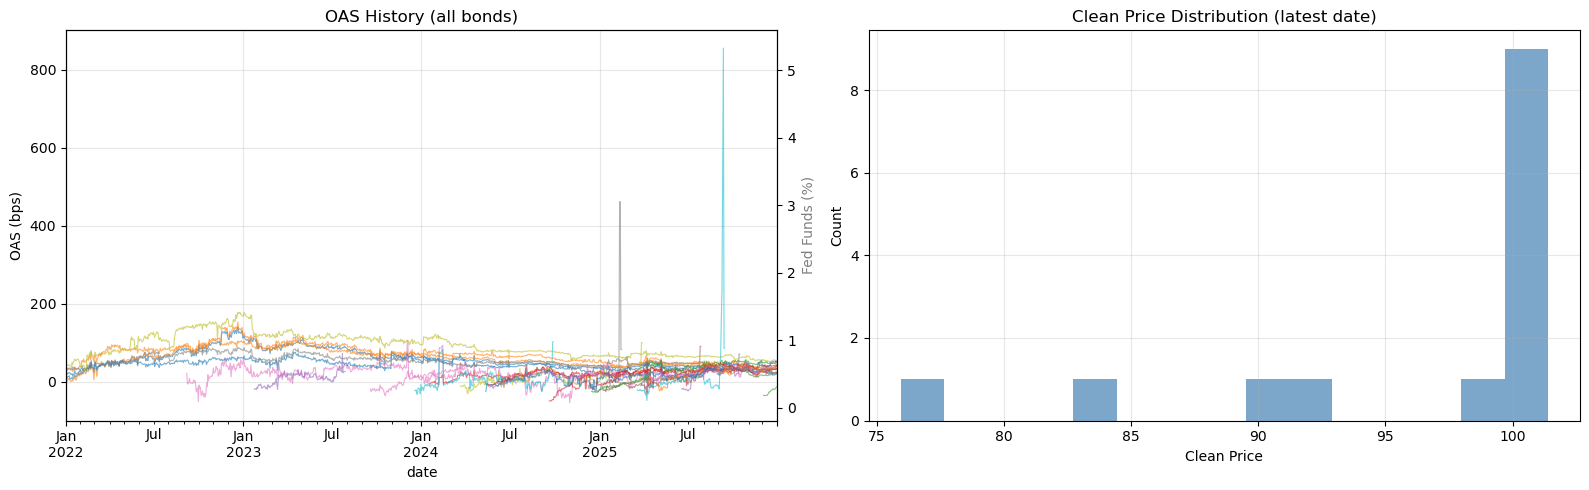

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# OAS time series
oas.plot(ax=axes[0], alpha=0.6, linewidth=0.8, legend=False)
axes[0].set_ylabel('OAS (bps)')
axes[0].set_title('OAS History (all bonds)')
axes[0].grid(True, alpha=0.3)

# Fed Funds rate for context
ff = rates.loc['2022':'2025', 'DFF']
ax2 = axes[0].twinx()
ax2.plot(ff.index, ff, 'k--', linewidth=1, alpha=0.4, label='Fed Funds')
ax2.set_ylabel('Fed Funds (%)', color='gray')

# Clean price distribution
clean.iloc[-1].dropna().hist(ax=axes[1], bins=15, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Clean Price')
axes[1].set_ylabel('Count')
axes[1].set_title('Clean Price Distribution (latest date)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

## Key Formulas

### Spread Decomposition (D.6.1)

$$\text{Z-spread} = \text{OAS} + \text{Option Cost}$$

The **Z-spread** prices the bond ignoring the embedded call. The **OAS** accounts for the issuer's call right. The difference is the **option cost**—the compensation for being short the call.

### Rolling Z-Score (Q2)

$$z_t = \frac{\text{OAS}_t - \overline{\text{OAS}}_{t-W:t}}{\sigma(\text{OAS}_{t-W:t})}$$

where $W$ is the rolling window (e.g., 60 trading days). A z-score above 1 means the bond is cheap relative to recent history; below $-1$ means expensive.

### Approximate Bond Return (Q2, Q3)

$$r_{\text{bond}} \approx -D_{\text{eff}} \times \frac{\Delta\text{OAS}}{10{,}000}$$

This spread-driven return approximation is used in Q2 for backtesting and refined in Q3 with carry and residual components.

### Return Decomposition (Q3)

For a bond with effective duration $D_{\text{eff}}$:

$$\text{Total Return} \approx \underbrace{\text{Coupon Accrual} - \text{Funding Cost}}_{\text{Carry}} + \underbrace{(-D_{\text{eff}} \times \Delta\text{OAS})}_{\text{Spread Return}} + \text{Residual}$$

The residual captures option repricing, curve moves, and model error.

where the carry component is:

$$\text{Carry (monthly)} = \frac{\text{Coupon}/12 - r_{\text{SOFR}} \times P_{\text{dirty}} / 12}{P_{\text{dirty}}}$$

and $r_{\text{SOFR}}$ is the annualized SOFR rate, $P_{\text{dirty}}$ is the dirty price at the start of the month.

### Call Moneyness (Q1)

$$\text{Call Moneyness} = \text{Coupon Rate} - s(T)$$

where $s(T)$ is the swap rate at the bond's maturity. Positive moneyness means the call is in the money (issuer has incentive to call).

## Questions


### Question 1: Cross-Section Anatomy

**Map the callable bond universe by its key characteristics and identify which bonds have the most expensive embedded calls.**

a) For each bond in the panel, compute the **call moneyness**: the difference between the bond's coupon rate and the current swap rate at the bond's maturity (interpolate the swap curve as needed). Positive moneyness means the call is in the money (the issuer has an incentive to call). Present the results in a table.

b) Compute the **option cost** for each bond: $\text{Option Cost} = \text{Z-spread} - \text{OAS}$ (both over the swap curve). Create a scatter plot of call moneyness vs. option cost. Describe the relationship. If implied vol data is available in the snapshot, compare it to option cost — how closely do they track across the moneyness spectrum?

c) Create a visualization showing how **effective duration** and **effective convexity** vary across the panel. Which bonds exhibit the most negative convexity? How does this relate to call moneyness?

d) Group bonds into three categories: deep OTM callables (moneyness < −100 bps), near-ATM callables (−100 to +100 bps), and deep ITM callables (moneyness > +100 bps), or justify alternative cutoffs. Summarize how OAS, option cost, duration, and convexity differ across groups.

e) Which moneyness group looks most attractive for a spread strategy, and why?

In [6]:
import bisect

today_date = pd.Timestamp(year=2026, month=3, day=4).date()
swap_points = swaps.columns
swap_curve = swaps.iloc[-1, :]
swap_curve_ts = swap_curve.name
swap_curve_date = swap_curve.name.date()

col_names = ['swap_rate', 'coupon_rate', 'moneyness', 'label']
rows = []
for bond in info.columns:
    mat_date = pd.Timestamp(info[bond].loc['Date Matures']).date()
    coupon_rate = float(info[bond].loc['Cpn Rate']) * 100

    ttm = (mat_date - swap_curve_date).days / 365
    ii = bisect.bisect_left(swap_points, ttm)
    swap_rate = swap_curve.loc[ttm] if ttm in swap_points else np.interp(ttm, swap_points[ii-1:ii+1], swap_curve.iloc[ii-1:ii+1])
    moneyness = coupon_rate - swap_rate
    if coupon_rate < swap_rate and abs(moneyness) > 1:
        label_moneyness = 'deep otm'
    elif coupon_rate > swap_rate and abs(moneyness) > 1:
        label_moneyness = 'deep itm'
    else:
        label_moneyness = 'near atm'

    # print(bond, mat_date, ttm, swap_rate, coupon_rate, moneyness, sep='\t')
    rows.append([swap_rate, coupon_rate, moneyness, label_moneyness])

moneyness_info = pd.DataFrame(rows, index=info.columns, columns=col_names)
display(moneyness_info)

,swap_rate,coupon_rate,moneyness,label
FHLB 2 01/28/31,3.456761,2.000,-1.456761,deep otm
FHLB 2 09/15/31,3.488433,2.000,-1.488433,deep otm
FHLB 4.25 03/28/30,3.420310,4.250,0.829690,near atm
FHLB 4.25 12/28/28,3.397979,4.250,0.852021,near atm
FHLB 4.75 06/15/28,3.400098,4.750,1.349902,deep itm
FHLB 5 01/15/30,3.414047,5.000,1.585953,deep itm
FHLB 5 09/28/32,3.544149,5.000,1.455851,deep itm
FHLB 5 12/15/27,3.421842,5.000,1.578158,deep itm
FHLB 5.25 03/28/29,3.397325,5.250,1.852675,deep itm
FHLB 5.5 12/28/28,3.397979,5.500,2.102021,deep itm


,swap_rate,coupon_rate,moneyness,label,option_cost,IV
FHLB 2 01/28/31,3.456761,2.000,-1.456761,deep otm,NaN,0.000000
FHLB 2 09/15/31,3.488433,2.000,-1.488433,deep otm,43.823,21.022839
FHLB 4.25 03/28/30,3.420310,4.250,0.829690,near atm,62.738,24.465900
FHLB 4.25 12/28/28,3.397979,4.250,0.852021,near atm,53.351,25.266815
FHLB 4.75 06/15/28,3.400098,4.750,1.349902,deep itm,NaN,NaN
FHLB 5 01/15/30,3.414047,5.000,1.585953,deep itm,NaN,NaN
FHLB 5 09/28/32,3.544149,5.000,1.455851,deep itm,143.611,NaN
FHLB 5 12/15/27,3.421842,5.000,1.578158,deep itm,NaN,NaN
FHLB 5.25 03/28/29,3.397325,5.250,1.852675,deep itm,NaN,NaN
FHLB 5.5 12/28/28,3.397979,5.500,2.102021,deep itm,NaN,NaN


Text(0.5, 1.0, 'Option Cost and Implied Vol vs Moneyness')

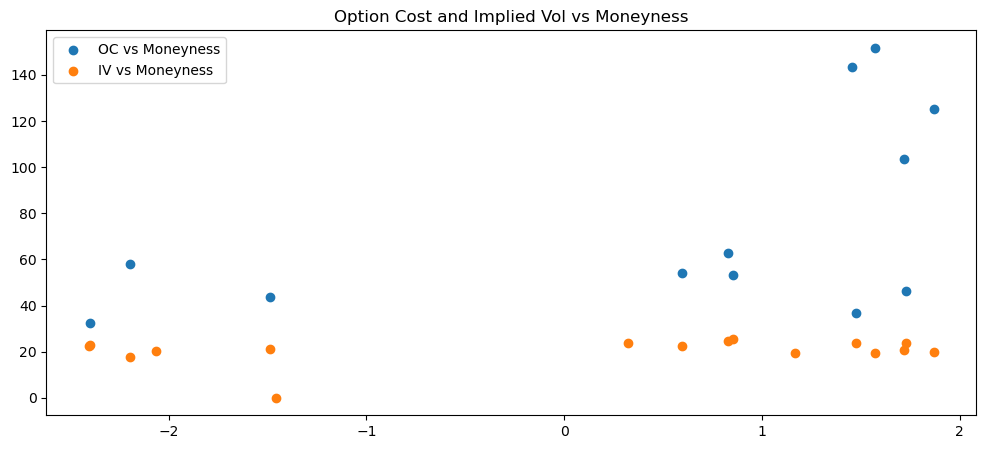

In [7]:
z = zsprd.loc[swap_curve_ts, :]
o = oas.loc[swap_curve_ts, :]
oc = z - o
moneyness_info['option_cost'] = oc
iv = quotes.loc['Implied Vol', :]
moneyness_info['IV'] = iv

display(moneyness_info)
plt.scatter(moneyness_info['moneyness'], moneyness_info['option_cost'], label='OC vs Moneyness')
plt.scatter(moneyness_info['moneyness'], moneyness_info['IV'], label='IV vs Moneyness')
plt.legend()
plt.title('Option Cost and Implied Vol vs Moneyness')

Text(0.5, 1.0, 'Effective Convexity vs Moneyness')

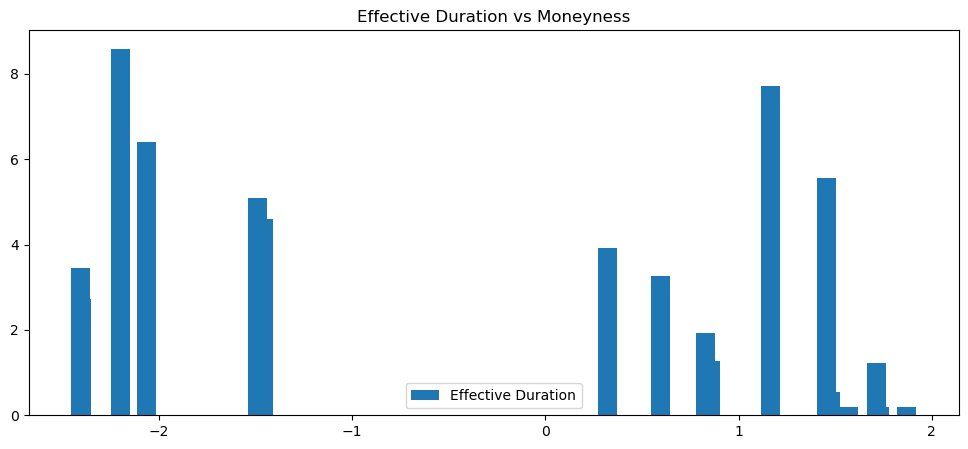

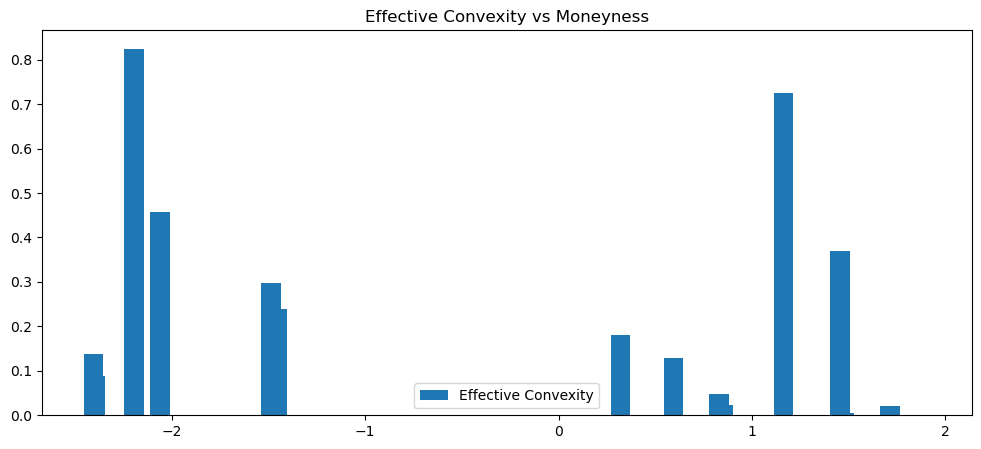

In [13]:
moneyness_info['Effective Duration'] = quotes.loc['Eff Duration', :]
moneyness_info['Effective Convexity'] = quotes.loc['Eff Convexity', :]

plt.figure(1) # Specify the figure number
plt.bar(moneyness_info['moneyness'], moneyness_info['Effective Duration'], label='Effective Duration', width=0.1)
plt.legend()
plt.title('Effective Duration vs Moneyness')

plt.figure(2) # Specify the figure number
plt.bar(moneyness_info['moneyness'], moneyness_info['Effective Convexity'], label='Effective Convexity', width=0.1)
plt.legend()
plt.title('Effective Convexity vs Moneyness')

In [9]:
moneyness_info['OAS'] = o
display(moneyness_info.sort_values('moneyness'))
display(moneyness_info.groupby('label')['OAS'].mean())
display(moneyness_info.groupby('label')['OAS'].std())
display(moneyness_info.groupby('label')['option_cost'].mean())
display(moneyness_info.groupby('label')['Effective Duration'].mean())
display(moneyness_info.groupby('label')['Effective Convexity'].mean())

,swap_rate,coupon_rate,moneyness,label,option_cost,IV,Effective Duration,Effective Convexity,OAS
FNMA 1 09/28/29,3.404566,1.000,-2.404566,deep otm,NaN,22.447554,3.437918,0.136820,46.92
FHLMC 1 12/28/28,3.397979,1.000,-2.397979,deep otm,32.248,22.676838,2.727172,0.088655,35.86
FNMA 1.5 09/28/35,3.696305,1.500,-2.196305,deep otm,57.808,17.836895,8.588169,0.824861,63.66
FHLMC 1.5 01/28/33,3.562248,1.500,-2.062248,deep otm,NaN,20.182705,6.412018,0.457418,47.66
FHLB 2 09/15/31,3.488433,2.000,-1.488433,deep otm,43.823,21.022839,5.100778,0.296774,42.31
FHLB 2 01/28/31,3.456761,2.000,-1.456761,deep otm,NaN,0.000000,4.590908,0.239862,38.73
FHLMC 3.75 06/28/30,3.428313,3.750,0.321687,near atm,NaN,23.649389,3.919288,0.181021,NaN
FHLMC 4 09/28/29,3.404566,4.000,0.595434,near atm,54.096,22.447554,3.272815,0.128589,11.09
FHLB 4.25 03/28/30,3.420310,4.250,0.829690,near atm,62.738,24.465900,1.935088,0.048317,28.07
FHLB 4.25 12/28/28,3.397979,4.250,0.852021,near atm,53.351,25.266815,1.267526,0.022526,18.58


label
deep itm    13.800000
deep otm    45.856667
near atm    19.246667
Name: OAS, dtype: float64

label
deep itm    16.734760
deep otm     9.845232
near atm     8.509608
Name: OAS, dtype: float64

label
deep itm    101.205833
deep otm     44.626333
near atm     56.728333
Name: option_cost, dtype: float64

label
deep itm    2.231993
deep otm    5.142827
near atm    2.598679
Name: Effective Duration, dtype: float64

label
deep itm    0.160465
deep otm    0.340732
near atm    0.095113
Name: Effective Convexity, dtype: float64

Deep ITM: low duration, medium convexity, low OAS, high option cost

Deep OTM: high duration, high convexity, high OAS, low option cost

Near ATM: low duration, low convexity, low OAS, low/medium option cost

Intuition: OTM options are more attractive for spread trading?

### Question 2: OAS Signal and Backtest

**Construct a mean-reversion strategy using OAS z-scores and backtest it over 2022–2025.**

a) For each bond, compute the **rolling OAS z-score** using a 60-trading-day window:

$$z_t = \frac{\text{OAS}_t - \overline{\text{OAS}}_{t-W:t}}{\sigma(\text{OAS}_{t-W:t})}$$

Plot the z-score time series for 3–4 representative bonds (one from each moneyness group).

b) Design a **long/short strategy**: go long bonds with $z > 1$ (OAS is wide relative to history, bond is cheap) and short bonds with $z < -1$ (OAS is tight, bond is expensive). Weight positions by equal notional within each leg. Rebalance positions monthly.

c) Compute monthly returns for the strategy. Approximate each bond's monthly return as $-D_{\text{eff}} \times \Delta\text{OAS} / 10{,}000$, where $D_{\text{eff}}$ is the snapshot effective duration and $\Delta\text{OAS}$ is the monthly OAS change in basis points. Report:
   - Annualized return
   - Annualized volatility
   - Sharpe ratio
   - Maximum drawdown
   - Hit rate (% of months with positive P&L when a position is on)

d) Test the sensitivity of results to the rolling window length (try 30, 60, and 90 days) and the z-score threshold (try 1.0 and 1.5). Which combination produces the best risk-adjusted returns? Discuss the trade-off between signal frequency and signal quality.

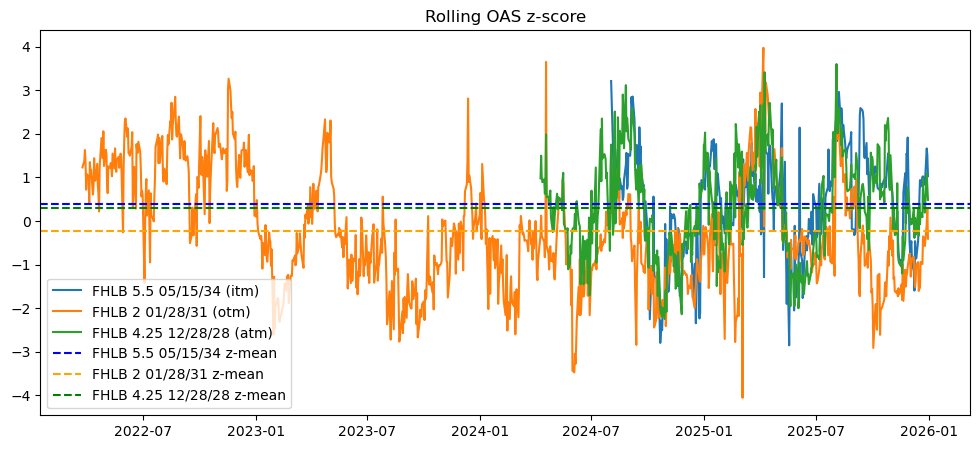

In [127]:
def make_rolling_oas_z(window):
    rolling_oas_means = oas.rolling(window=window, min_periods=window).mean()
    rolling_oas_stds = oas.rolling(window=window, min_periods=window).std()
    rolling_oas_z = (oas - rolling_oas_means) / rolling_oas_stds
    rolling_oas_z = rolling_oas_z.dropna(axis=0, how='all')
    return rolling_oas_z
# display(rolling_oas_z.count())
deep_itm_bond = 'FHLB 5.5 05/15/34'
deep_otm_bond = 'FHLB 2 01/28/31'
near_atm_bond = 'FHLB 4.25 12/28/28'
representative_bonds = [deep_itm_bond, deep_otm_bond, near_atm_bond]

rolling_oas_z = make_rolling_oas_z(60)
plt.plot(rolling_oas_z[representative_bonds], label=[f"{b} ({m})" for b, m in zip(representative_bonds, ['itm', 'otm', 'atm'])])
for bond, color in zip(representative_bonds, ['blue', 'orange', 'green']):
    plt.axhline(rolling_oas_z[bond].mean(), label=f"{bond} z-mean", color=color, linestyle='--')
plt.title("Rolling OAS z-score")
plt.legend()

In [128]:
def make_strategy_positions(rolling_oas_z, threshold):
    # rebalance at end-of-month
    last_dates_of_month = rolling_oas_z.groupby(pd.Grouper(freq='ME')).apply(lambda x: x.index.max())
    durations = moneyness_info['Effective Duration'].dropna()
    usable_bonds = list(durations.index.intersection(oas.columns))
    # print(usable_bonds)
    rolling_oas_z_snapshots = rolling_oas_z.loc[last_dates_of_month, usable_bonds].dropna(axis=1, how='all')
    # display(rolling_oas_z_snapshots)

    # determine long/short at each date
    direction_snapshots = rolling_oas_z_snapshots.map(lambda x: 1 if x > threshold else (-1 if x < -threshold else 0)).replace(np.nan, 0)
    # display(direction_snapshots)

    # determine position weights
    long_weights = direction_snapshots[direction_snapshots == 1].div(direction_snapshots[direction_snapshots == 1].sum(axis=1), axis=0)
    short_weights = direction_snapshots[direction_snapshots == -1].div(direction_snapshots[direction_snapshots == -1].sum(axis=1), axis=0)
    weights = long_weights.replace(np.nan, 0) - short_weights.replace(np.nan, 0)
    weights = weights.div(weights.abs().sum(axis=1), axis=0).replace(np.nan, 0) # magnitude of weights sum to 1, showing that we do not withdraw or inject capital
    
    # generate returns data
    oas_delta = (rolling_oas_z_snapshots - rolling_oas_z_snapshots.shift(1)).replace(np.nan, 0)
    oas_monthly_return = (oas_delta * -durations / 10000).dropna(how='all', axis=1)
    # display(oas_monthly_return.head())

    per_bond_pnl = weights.shift(1).multiply(oas_monthly_return).dropna(how='all', axis=0)
    # display(per_bond_pnl.head())

    strategy_monthly_return = per_bond_pnl.sum(axis=1)
    # display(strategy_monthly_return)
    return weights, strategy_monthly_return

weights, returns = make_strategy_positions(rolling_oas_z, 1)
display(weights)

,FHLB 2 01/28/31,FHLB 2 09/15/31,FHLB 4.25 03/28/30,FHLB 4.25 12/28/28,FHLB 5 09/28/32,FHLMC 1 12/28/28,FHLMC 1.5 01/28/33,FHLMC 4 09/28/29,FNMA 1 09/28/29,FNMA 1.5 09/28/35,FHLB 4.875 09/28/28,FHLB 5.125 05/15/29,FHLB 5.25 05/15/35,FHLB 5.375 12/15/34,FHLB 5.5 05/15/34
date,,,,,,,,,,,,,,,
2022-03-31,0.000000,0.000000,0.0,0.000000,0.000000,0.500000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2022-04-29,0.333333,0.333333,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.0,0.000000,0.000000
2022-05-31,0.250000,0.250000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.250000,0.000000,0.000000,0.0,0.000000,0.000000
2022-06-30,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,0.000000,0.000000,0.0,0.000000,0.000000
2022-07-29,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
2022-08-31,0.250000,0.250000,0.0,0.000000,0.000000,0.000000,0.250000,0.000000,0.000000,0.250000,0.000000,0.000000,0.0,0.000000,0.000000
2022-09-30,0.000000,0.250000,0.0,0.000000,0.000000,-0.500000,0.000000,0.000000,0.000000,0.250000,0.000000,0.000000,0.0,0.000000,0.000000
2022-10-31,0.166667,0.166667,0.0,0.000000,0.000000,0.166667,0.166667,0.000000,0.166667,0.166667,0.000000,0.000000,0.0,0.000000,0.000000
2022-11-30,0.166667,0.166667,0.0,0.000000,0.166667,0.166667,0.000000,0.000000,0.166667,0.166667,0.000000,0.000000,0.0,0.000000,0.000000


In [129]:
def performance(strategy_monthly_returns):
    annualized_return = strategy_monthly_returns.mean() * 12
    annualized_vol = strategy_monthly_returns.std() * np.sqrt(12)
    sharpe = annualized_return / annualized_vol
    cumulative_returns = (1 + strategy_monthly_returns).cumprod()
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    active_months = ~weights.eq(0).all(axis=1) # if all weights are 0, then we did not put on a position
    hit_rate = (active_months > 0).sum() / len(active_months)

    results = []
    results.append(f"Annualized Return: {annualized_return}")
    results.append(f"Annualized Volatility: {annualized_vol}")
    results.append(f"Sharpe Ratio: {sharpe}")
    results.append(f"Maximum Drawdown: {max_drawdown}")
    results.append(f"Hit Rate: {hit_rate}")
    return results

print(*performance(returns), sep='\n')

Annualized Return: 0.0056316285252573026
Annualized Volatility: 0.001887875022924872
Sharpe Ratio: 2.9830515563113167
Maximum Drawdown: -0.000516220872261235
Hit Rate: 0.9782608695652174


In [131]:
import itertools

for window, threshold in itertools.product((30, 60, 90), (1, 1.5)):
    rolling_z = make_rolling_oas_z(window)
    weights, returns = make_strategy_positions(rolling_z, threshold)
    results = performance(returns)
    print(f"Window: {window}")
    print(f"Threshold: {threshold}", *results, sep='\t\n')
    print("")

Window: 30
Threshold: 1	
Annualized Return: 0.007116160615807974	
Annualized Volatility: 0.0015400169836803685	
Sharpe Ratio: 4.620832556535583	
Maximum Drawdown: -6.655701550442594e-05	
Hit Rate: 0.9361702127659575

Window: 30
Threshold: 1.5	
Annualized Return: 0.005756491430421712	
Annualized Volatility: 0.0017432609032363461	
Sharpe Ratio: 3.3021399262352777	
Maximum Drawdown: 0.0	
Hit Rate: 0.723404255319149

Window: 60
Threshold: 1	
Annualized Return: 0.0056316285252573026	
Annualized Volatility: 0.001887875022924872	
Sharpe Ratio: 2.9830515563113167	
Maximum Drawdown: -0.000516220872261235	
Hit Rate: 0.9782608695652174

Window: 60
Threshold: 1.5	
Annualized Return: 0.005277637686349187	
Annualized Volatility: 0.001573267355446815	
Sharpe Ratio: 3.35457140712763	
Maximum Drawdown: -0.00032097611582390813	
Hit Rate: 0.717391304347826

Window: 90
Threshold: 1	
Annualized Return: 0.0046418465028002604	
Annualized Volatility: 0.00216941762854632	
Sharpe Ratio: 2.1396740036221895	
Maxi

### Question 3: Return Decomposition

**Decompose monthly strategy returns into carry, spread compression, and residual components.**

*Note: This question uses the subset of bonds with dirty price data (15 bonds). Effective duration is available as a snapshot in the `quotes` sheet—use it as a constant approximation, or compute numerical duration from price data if you prefer.*

a) For each bond with dirty price data, compute monthly returns. Decompose each bond's return into:

   - **Carry**: coupon accrual minus funding cost (use SOFR as the funding rate)
   - **Spread return**: $-D_{\text{eff}} \times \Delta \text{OAS}$, where $D_{\text{eff}}$ is effective duration and $\Delta \text{OAS}$ is the monthly change in OAS
   - **Residual**: total return minus carry minus spread return (captures option repricing, curve moves, model error)

b) Aggregate across the long and short legs of the Q2 strategy. Create a stacked bar chart showing the monthly decomposition. Which component dominates the strategy's P&L?

c) Compare the decomposition during two periods: (i) the pause regime (2023 H2–2024 H2) when rates were stable, and (ii) the hiking regime (2022–2023 H1) when rates moved sharply. Does the relative importance of carry vs. spread return change across regimes? Comment on what drives the residual.

### Question 4: The Value of Modeling the Option

**Assess whether OAS-based signals outperform simpler spread signals that ignore the embedded call.**

a) Using the bonds that have both OAS and Z-spread time series, compute z-scores on the **Z-spread** (from the `z_spread` sheet) instead of OAS. Alternatively, approximate a naive spread as yield minus the interpolated swap rate (using the `ytm` sheet and `sofr_swaps.xlsx`).

b) Run the same long/short strategy from Q2, but using the naive spread z-score instead of OAS z-score. Compare Sharpe ratios, drawdowns, and hit rates.

c) Examine how the **gap** between OAS and Z-spread z-scores varies over time. Are there episodes where the signals disagree, and which produces better subsequent P&L?

d) Summarize: how much value comes from correctly modeling the embedded option?

### Question 5: Regime Analysis

**Analyze how option cost and strategy performance vary across rate regimes.**

Use the following regime definitions:

| Regime | Start | End | Description |
|--------|-------|-----|-------------|
| Hiking Start | 2022-01-01 | 2022-09-30 | Fed Funds from 0.25% to ~3.25% |
| Aggressive Hiking | 2022-10-01 | 2023-06-30 | Fed Funds from ~3.25% to 5.25% |
| Pause | 2023-07-01 | 2024-08-31 | Holding at 5.25–5.50% |
| Easing | 2024-09-01 | 2025-12-31 | First cuts begin |

a) For each regime, compute the **average option cost** for bonds in each moneyness group (deep OTM, near ATM, deep ITM from Q1). How does option cost evolve as the rate cycle progresses?

b) Compute the **Sharpe ratio of the Q2 strategy** in each regime separately. Explain the variation across regimes.

c) During the hiking regime, many previously high-coupon callable bonds saw their calls go from ITM to OTM as rates rose above their coupon. Pick one or two specific bonds and trace their OAS and option cost through the hiking period.

d) Based on your analysis, when should a portfolio manager use or avoid this strategy?

e) Propose one modification to the Q2 strategy that might improve performance. Describe the logic, implement a simple version, and compare its Sharpe ratio to the baseline.

## Deliverables

Review the [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html) for submission standards, conciseness expectations, and AI usage policy.

Submit a Jupyter notebook with analysis for all five questions (Q1–Q5), including code, figures, and written interpretation. Include a summary section (1–2 paragraphs) synthesizing your findings: What did you learn about trading callable bonds on OAS signals? What are the limitations of this approach?

**Conciseness is a graded criterion** — see [Project Guidelines](https://markhendricks.github.io/finm-fixedincome/discussions/11.0.%20Project%20Guidelines_copy.html).